In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nabilabdul/ames-house-price-prediction-regression/data_description.txt
/kaggle/input/datasets/nabilabdul/ames-house-price-prediction-regression/data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("/kaggle/input/datasets/nabilabdul/ames-house-price-prediction-regression/data.csv")

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
media_sale_price=df['SalePrice'].mean()
median_sale_price = df['SalePrice'].median()
moda_sale_price=df['SalePrice'].mode()

print(media_sale_price)
print(median_sale_price)
print(moda_sale_price)

180921.19589041095
163000.0
0    140000
Name: SalePrice, dtype: int64


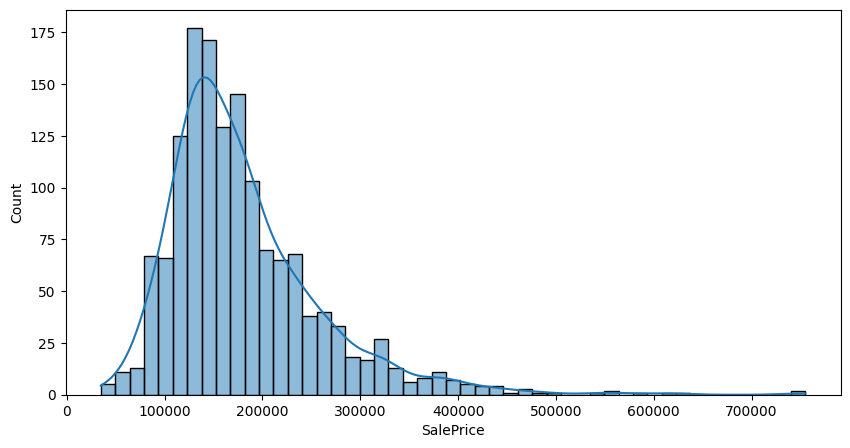

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'],kde=True)
plt.show()

In [7]:
# Skewness (Assimetria): 
# Mede a direção da cauda; >0 indica cauda longa à direita <0 à esquerda.
# Kurtosis (Curtose):
# Mede o achatamento e o peso das caudas,
# valores altos (>0) indicam forte presença de outliers (caudas grossas).
# Ambas ajudam a entender o comportamento e a normalidade da distribuição
# antes de aplicar transformações nos dados.

skew=df['SalePrice'].skew()
kurtosis=df['SalePrice'].kurtosis()

print('skew: ',skew)
print('kurtosis: ',kurtosis)

skew:  1.8828757597682129
kurtosis:  6.536281860064529


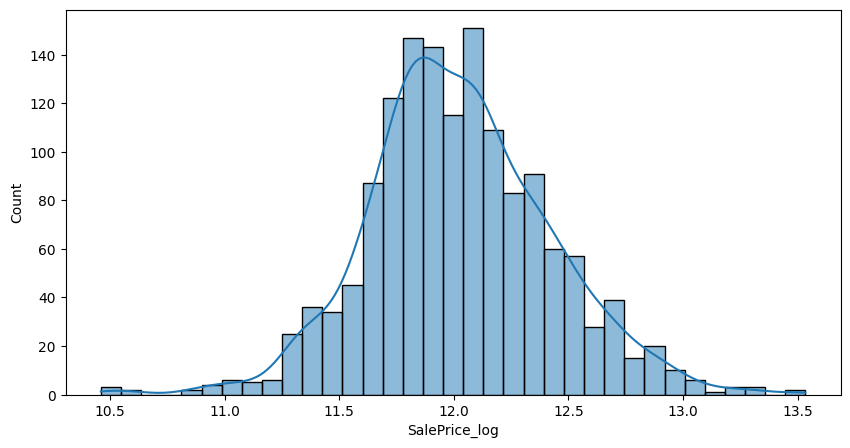

In [8]:
#aplicando a transformação logaritmica

df['SalePrice_log']=np.log1p(df['SalePrice'])
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice_log'],kde=True)
plt.show()

In [9]:
print('skew log',df['SalePrice_log'].skew())
print('Kurtosis log ',df['SalePrice_log'].kurtosis())

skew log 0.12134661989685333
Kurtosis log  0.809519155707878


In [10]:
X=df.drop(columns=['SalePrice_log'])

y=df['SalePrice_log']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
df_treino = pd.concat([X_train, y_train], axis=1)

In [13]:
colunas_numericas = df_treino.select_dtypes(include=['number']).columns.tolist()

In [14]:
correlacoes=df_treino[colunas_numericas].corr()['SalePrice_log']

In [15]:
correlacoes.sort_values(ascending=False)

SalePrice_log    1.000000
SalePrice        0.952971
OverallQual      0.807946
GrLivArea        0.689012
GarageCars       0.684451
GarageArea       0.654520
TotalBsmtSF      0.597214
FullBath         0.583747
1stFlrSF         0.580948
YearBuilt        0.576725
YearRemodAdd     0.562152
GarageYrBlt      0.530321
TotRmsAbvGrd     0.520082
Fireplaces       0.481761
MasVnrArea       0.422218
BsmtFinSF1       0.340878
WoodDeckSF       0.340702
LotFrontage      0.334227
2ndFlrSF         0.313633
HalfBath         0.312282
OpenPorchSF      0.305512
LotArea          0.257676
BsmtUnfSF        0.235227
BsmtFullBath     0.231205
BedroomAbvGr     0.193340
ScreenPorch      0.123040
PoolArea         0.084116
3SsnPorch        0.059252
MoSold           0.055651
BsmtFinSF2       0.010704
Id              -0.015302
YrSold          -0.018459
MiscVal         -0.018609
LowQualFinSF    -0.024265
BsmtHalfBath    -0.030136
OverallCond     -0.034448
MSSubClass      -0.079380
KitchenAbvGr    -0.157575
EnclosedPorc

In [16]:
# Filtra o índice (nomes das colunas) onde o valor absoluto da correlação atende aos critérios
colunas_correlacionadas = correlacoes[(correlacoes > 0.6) & (correlacoes != 1)].index.tolist()

In [17]:
colunas_correlacionadas

['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'SalePrice']

In [18]:
# Calcula Q1 e Q3 para todas as colunas correlacionadas de uma vez
q1 = df_treino[colunas_correlacionadas].quantile(0.25)
q3 = df_treino[colunas_correlacionadas].quantile(0.75)
iqr = q3 - q1

# Define os limites para detecção de outliers
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
    



In [19]:

# Retorna True se o valor for menor que o limite inferior OU maior que o limite superior
df_outliers = (df_treino[colunas_correlacionadas] < limite_inferior) | (df_treino[colunas_correlacionadas] > limite_superior)

# (Opcional) Adicione um sufixo para identificar as colunas de diagnóstico ao juntar
df_outliers = df_outliers.add_suffix('_is_outlier')


print(df_outliers.sum())

OverallQual_is_outlier     2
GrLivArea_is_outlier      23
GarageCars_is_outlier      4
GarageArea_is_outlier     18
SalePrice_is_outlier      48
dtype: int64


In [20]:
df_outliers

,OverallQual_is_outlier,GrLivArea_is_outlier,GarageCars_is_outlier,GarageArea_is_outlier,SalePrice_is_outlier
254,False,False,False,False,False
1066,False,False,False,False,False
638,False,False,False,False,False
799,False,False,False,False,False
380,False,False,False,False,False
...,...,...,...,...,...
1095,False,False,False,False,False
1130,False,False,False,False,False
1294,False,False,False,False,False
860,False,False,False,False,False


In [21]:
df_treino[colunas_correlacionadas].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   OverallQual  1168 non-null   int64
 1   GrLivArea    1168 non-null   int64
 2   GarageCars   1168 non-null   int64
 3   GarageArea   1168 non-null   int64
 4   SalePrice    1168 non-null   int64
dtypes: int64(5)
memory usage: 54.8 KB


In [22]:
# Junta os dados originais com a tabela que aponta os outliers
df_analise = pd.concat([df_treino, df_outliers], axis=1)

In [23]:
#desvio padrão das variaveis fortemente correlacionadas

df_analise[colunas_correlacionadas].std()

OverallQual        1.367619
GrLivArea        524.432686
GarageCars         0.740161
GarageArea       211.095373
SalePrice      77263.583862
dtype: float64

In [24]:
df_analise[colunas_correlacionadas].isna().sum().sort_values(ascending=False)

OverallQual    0
GrLivArea      0
GarageCars     0
GarageArea     0
SalePrice      0
dtype: int64

Transformar as categoricas em numericas


In [25]:
# Substitui o nome do bairro pela média do SalePrice_log daquele bairro
df_analise['Neighborhood_encoded'] = df_treino.groupby('Neighborhood')['SalePrice_log'].transform('mean')